<font color="#CA0032"><h1>Practica B3-T5 · Laboratorio de estrategias</h1></font>

## Comparativa de arquitecturas para prediccion de ventas Rossmann

**Grupo:** Alonso Diaz · Raul Rodriguez · Piettro Enrico

---

Este notebook recoge **tres estrategias** para predecir las ventas de las 9 tiendas objetivo,
tal como sugiere el enunciado. El objetivo es comparar sus R2 y justificar la eleccion final.

| Seccion | Responsable | Estrategia |
|---------|-------------|------------|
| A | Alonso | **Un modelo por tienda** (9 modelos LSTM pequenos) |
| B | Raul | **Un modelo por grupo** (2 modelos: cierran-domingos vs nunca-cierran) |
| C | Piettro | **Modelo global** con embedding de `Store` (1 modelo para todas) |

**Base comun:** mismas tiendas, mismo split, mismas metricas -> los R2 son comparables directamente.

## 0. Configuracion comun

> **Todos los miembros usan exactamente esta celda sin modificar.**

In [1]:
COLAB = False          # True en Google Colab (descarga datos automaticamente)
RUTA_DATA = 'data'     # ruta local; en Colab se sobreescribe abajo

# Tiendas objetivo del enunciado
TIENDAS        = [1, 2, 3, 4, 5, 562, 682, 733, 769]
TIENDAS_CIERRAN = [1, 2, 3, 4, 5]          # cierran los domingos
TIENDAS_ABIERTAS = [562, 682, 733, 769]    # nunca cierran

# Split temporal (enunciado)
F_TEST = '2015-01-01'   # test = desde esta fecha (inclusive)
F_VAL  = '2014-11-15'   # validacion = desde aqui hasta F_TEST

W    = 28               # ventana lookback (dias)
SEED = 7

## 1. Imports

In [2]:
import numpy as np, pandas as pd, zipfile, os, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, LSTM, GRU,
                                     Embedding, Flatten, concatenate, Dropout)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


## 2. Carga de datos

In [3]:
if COLAB:
    import subprocess
    subprocess.run(['git','clone',
        'https://github.com/alonsodt/B3_T5-NN-con-entrdas-hetereogeneas-.git'], check=True)
    RUTA_DATA = 'B3_T5-NN-con-entrdas-hetereogeneas-/data'

with zipfile.ZipFile(os.path.join(RUTA_DATA, 'train.zip')) as z:
    train = pd.read_csv(z.open('train.csv'), parse_dates=['Date'], low_memory=False)
store = pd.read_csv(os.path.join(RUTA_DATA, 'store.csv'))

df = (train.merge(store, on='Store', how='left')
           .sort_values(['Store','Date'])
           .reset_index(drop=True))

# Feature engineering basico
df['StateHoliday'] = df['StateHoliday'].astype(str).replace('0','n')
df['Month']        = df.Date.dt.month
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
df['CompDistLog']  = np.log1p(df['CompetitionDistance'])
df['Promo2']       = df['Promo2'].fillna(0).astype(int)
df['y']            = np.log1p(df['Sales'])   # objetivo en escala log

# Restringimos a las 9 tiendas del enunciado
df = df[df.Store.isin(TIENDAS)].reset_index(drop=True)
print('Filas:', len(df), '| Tiendas:', df.Store.nunique())

Filas: 8352 | Tiendas: 9


## 3. Analisis exploratorio (EDA)

Un EDA orientado a la **toma de decisiones de modelado**: cada bloque termina con la implicacion
practica para la arquitectura o el preprocesado. Trabajamos sobre las 9 tiendas objetivo.

### 3.1 Resumen por tienda y metadatos

Estadisticos descriptivos de ventas y atributos estaticos (`StoreType`, `Assortment`, distancia a la
competencia). Sirve para detectar tiendas de escala/comportamiento distinto.

In [4]:
resumen = []
for sid in TIENDAS:
    g  = df[df.Store == sid]
    go = g[g.Open == 1]
    resumen.append({
        'Store': sid,
        'Familia': 'cierra_dom' if sid in TIENDAS_CIERRAN else 'abre_siempre',
        'StoreType': g['StoreType'].iloc[0],
        'Assortment': g['Assortment'].iloc[0],
        'CompDist_m': int(g['CompetitionDistance'].iloc[0]),
        'dias': len(g),
        '%_abierto': round(100*g['Open'].mean(), 1),
        'venta_media': int(go['Sales'].mean()),
        'venta_mediana': int(go['Sales'].median()),
        'venta_std': int(go['Sales'].std()),
        'venta_max': int(go['Sales'].max()),
        'promo_%': round(100*g['Promo'].mean(), 1),
    })
resumen = pd.DataFrame(resumen).set_index('Store')
print('Rango de fechas:', df.Date.min().date(), '->', df.Date.max().date())
resumen

Rango de fechas: 2013-01-01 -> 2015-07-17


,Familia,StoreType,Assortment,CompDist_m,dias,%_abierto,venta_media,venta_mediana,venta_std,venta_max,promo_%
Store,,,,,,,,,,,
1,cierra_dom,c,a,1270,928,82.9,4763,4648,1014,9528,38.3
2,cierra_dom,a,a,570,928,83.2,4956,4783,1615,10682,38.3
3,cierra_dom,a,a,14130,928,82.7,6950,6621,2199,15689,38.3
4,cierra_dom,c,c,620,928,83.2,9633,9422,1939,17412,38.3
5,cierra_dom,a,a,29910,928,82.7,4681,4617,1769,11692,38.3
562,abre_siempre,b,c,1210,928,100.0,17980,18041,2933,28680,38.3
682,abre_siempre,b,a,150,928,100.0,11217,11142,3262,22052,38.3
733,abre_siempre,b,b,860,928,100.0,14943,14803,1841,22137,38.3
769,abre_siempre,b,b,840,928,100.0,10817,10727,1859,18177,38.3


### 3.2 Series temporales y las dos familias

El profesor distingue dos perfiles: tiendas de barrio que **cierran domingos** (muy periodicas) y tiendas
que **abren siempre** (mas irregulares). Visualizamos la serie completa y un zoom de 60 dias para ver el
ciclo semanal.

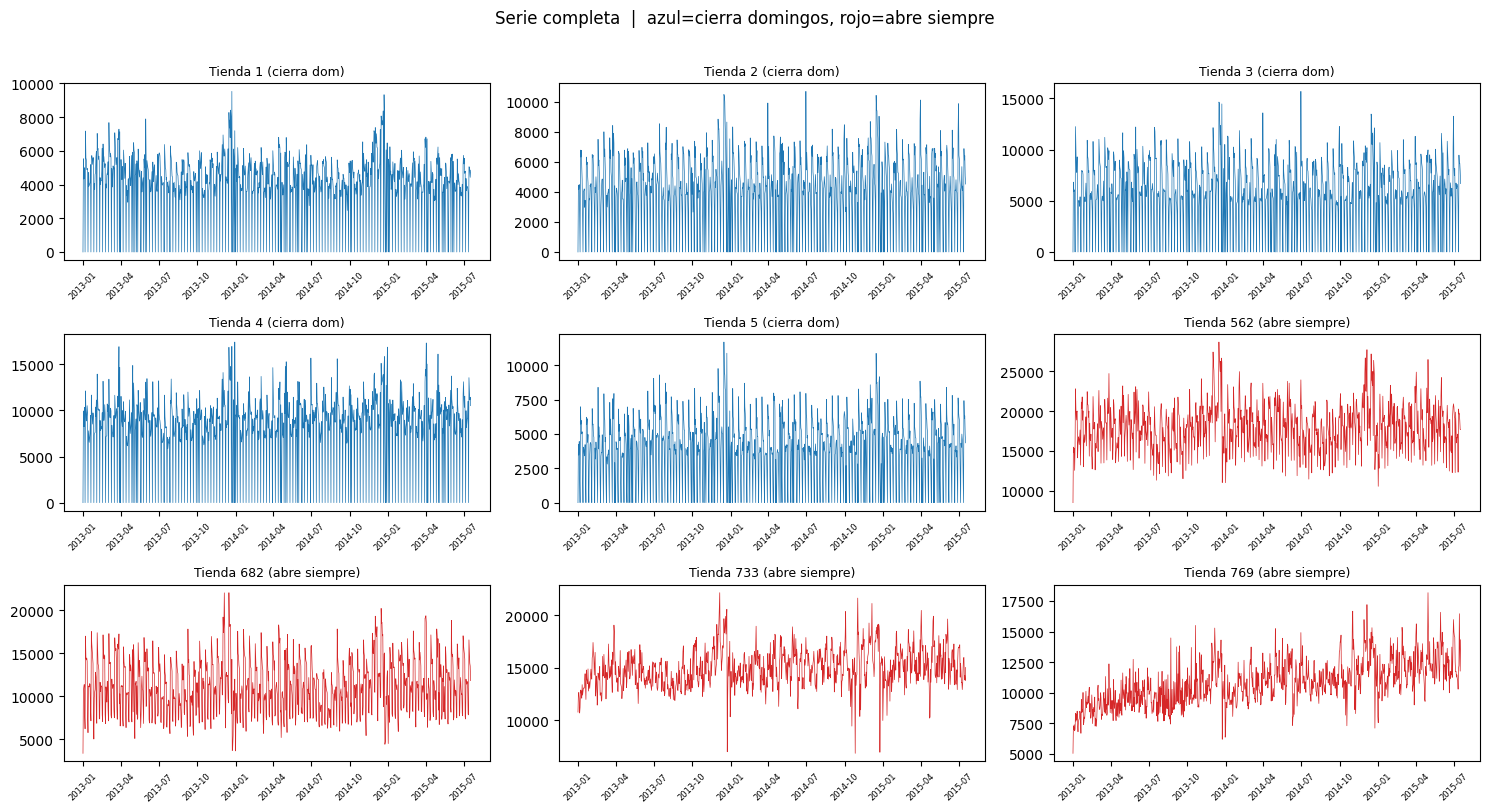

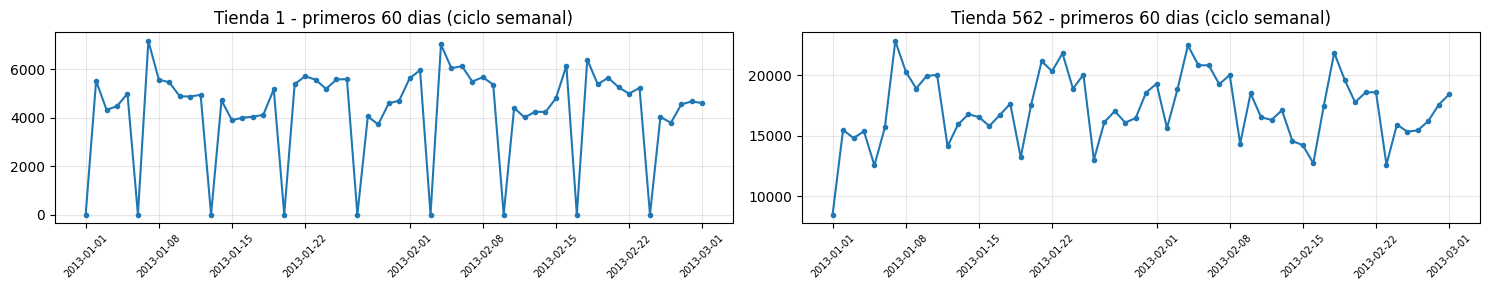

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
for ax, sid in zip(axes.flat, TIENDAS):
    g = df[df.Store == sid]
    color = 'tab:blue' if sid in TIENDAS_CIERRAN else 'tab:red'
    ax.plot(g.Date, g.Sales, lw=0.5, color=color)
    fam = 'cierra dom' if sid in TIENDAS_CIERRAN else 'abre siempre'
    ax.set_title(f'Tienda {sid} ({fam})', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
plt.suptitle('Serie completa  |  azul=cierra domingos, rojo=abre siempre', y=1.01)
plt.tight_layout(); plt.show()

# Zoom 60 dias: una tienda de cada familia
fig, axes = plt.subplots(1, 2, figsize=(15, 3))
for ax, sid in zip(axes, [1, 562]):
    g = df[df.Store == sid].iloc[:60]
    ax.plot(g.Date, g.Sales, 'o-', ms=3)
    ax.set_title(f'Tienda {sid} - primeros 60 dias (ciclo semanal)')
    ax.tick_params(axis='x', rotation=45, labelsize=7); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 3.3 Distribucion de ventas y transformacion logaritmica

Las ventas presentan **asimetria a la derecha** (cola de dias de alto volumen). Aplicar `log1p(Sales)`
reduce esa asimetria y estabiliza el entrenamiento (la red parte de pesos pequenos y predice mejor
magnitudes acotadas). **Decision:** el objetivo del modelo es `y = log1p(Sales)`; al evaluar
des-transformamos con `expm1`. El valor de asimetria se imprime en la propia figura.

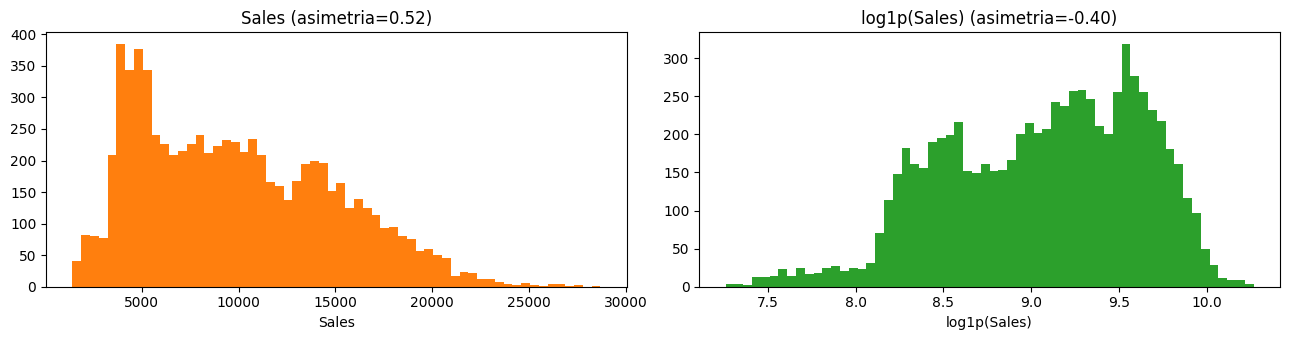

In [6]:
ventas = df[df.Open == 1]['Sales']
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
ax[0].hist(ventas, bins=60, color='tab:orange')
ax[0].set_title(f'Sales (asimetria={ventas.skew():.2f})'); ax[0].set_xlabel('Sales')
ax[1].hist(np.log1p(ventas), bins=60, color='tab:green')
ax[1].set_title(f'log1p(Sales) (asimetria={np.log1p(ventas).skew():.2f})'); ax[1].set_xlabel('log1p(Sales)')
plt.tight_layout(); plt.show()

### 3.4 Estacionalidad y efecto de promociones/festivos

Cuatro vistas en un panel:
- **Dia de la semana**: revela el ciclo semanal (y el cierre dominical de la familia 1).
- **Mes**: ciclo anual (caidas en verano, picos en diciembre).
- **Promo**: cuanto sube la venta media con promocion activa.
- **Festivo escolar**: efecto de `SchoolHoliday`.

**Decision:** estas variables de calendario se conocen de antemano -> entran como exogenas/categoricas
(embeddings de `DayOfWeek` y `Month`); `Promo` y `SchoolHoliday` ademas viajan dentro de la ventana LSTM.

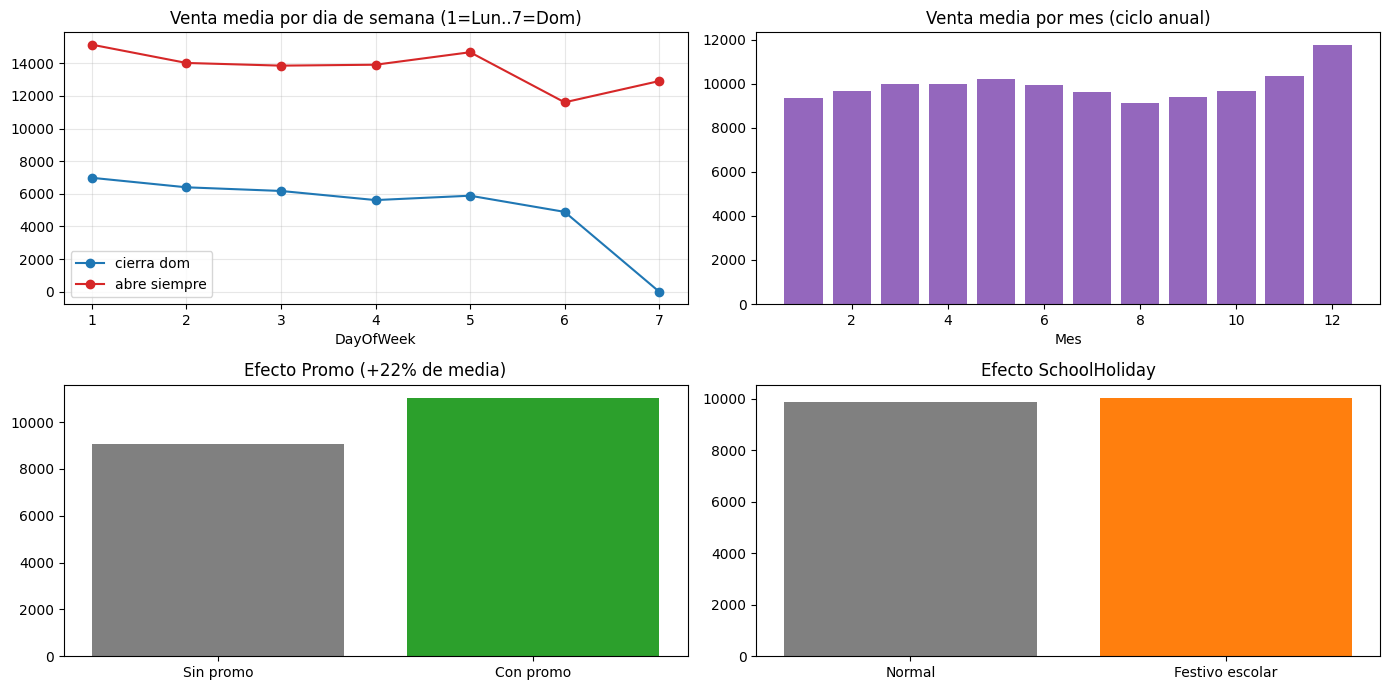

In [7]:
op = df[df.Open == 1]
fig, ax = plt.subplots(2, 2, figsize=(14, 7))

# ventas por dia de semana, por familia
for fam, tiendas, col in [('cierra dom', TIENDAS_CIERRAN, 'tab:blue'),
                          ('abre siempre', TIENDAS_ABIERTAS, 'tab:red')]:
    sub = df[df.Store.isin(tiendas)].groupby('DayOfWeek')['Sales'].mean()
    ax[0,0].plot(sub.index, sub.values, 'o-', label=fam, color=col)
ax[0,0].set_title('Venta media por dia de semana (1=Lun..7=Dom)')
ax[0,0].set_xlabel('DayOfWeek'); ax[0,0].legend(); ax[0,0].grid(alpha=.3)

# ventas por mes
mes = op.groupby('Month')['Sales'].mean()
ax[0,1].bar(mes.index, mes.values, color='tab:purple')
ax[0,1].set_title('Venta media por mes (ciclo anual)'); ax[0,1].set_xlabel('Mes')

# efecto promo
pr = op.groupby('Promo')['Sales'].mean()
ax[1,0].bar(['Sin promo','Con promo'], pr.values, color=['gray','tab:green'])
inc = 100*(pr.get(1,0)-pr.get(0,0))/pr.get(0,1)
ax[1,0].set_title(f'Efecto Promo (+{inc:.0f}% de media)')

# efecto festivo escolar
sh = op.groupby('SchoolHoliday')['Sales'].mean()
ax[1,1].bar(['Normal','Festivo escolar'], [sh.get(0,0), sh.get(1,0)], color=['gray','tab:orange'])
ax[1,1].set_title('Efecto SchoolHoliday')
plt.tight_layout(); plt.show()

### 3.5 Autocorrelacion, heterocedasticidad y la trampa de `Customers`

- **Autocorrelacion (ACF):** picos marcados en multiplos de 7 confirman la estacionalidad semanal y
  justifican los lags `lag_7`, `lag_14` y una ventana `W=28` (cubre 4 semanas).
- **Heterocedasticidad:** la desviacion movil de las ventas no es constante (varia con el nivel), tal como
  comento el profesor; el `log` la atenua.
- **`Customers`:** esta casi perfectamente correlacionada con `Sales`. Usarla seria hacer trampa
  (no se conoce de antemano), por eso el enunciado la **prohibe** como entrada.

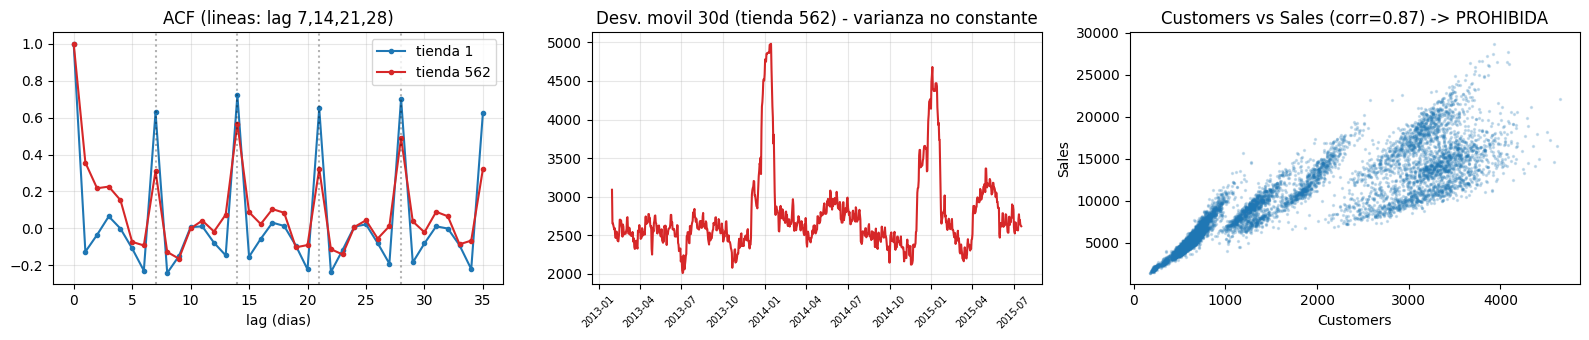

In [8]:
def acf(serie, nlags=35):
    x = np.asarray(serie, dtype=float)
    return [1.0] + [np.corrcoef(x[k:], x[:-k])[0,1] for k in range(1, nlags+1)]

fig, ax = plt.subplots(1, 3, figsize=(16, 3.5))

# ACF para una tienda de cada familia
for sid, col in [(1,'tab:blue'), (562,'tab:red')]:
    serie = df[df.Store == sid].sort_values('Date')['Sales'].values
    a = acf(serie, 35)
    ax[0].plot(range(36), a, 'o-', ms=3, label=f'tienda {sid}', color=col)
for k in [7,14,21,28]:
    ax[0].axvline(k, color='k', ls=':', alpha=.3)
ax[0].set_title('ACF (lineas: lag 7,14,21,28)'); ax[0].set_xlabel('lag (dias)')
ax[0].legend(); ax[0].grid(alpha=.3)

# heterocedasticidad: desviacion movil 30 dias
g = df[df.Store == 562].sort_values('Date')
roll = g['Sales'].rolling(30).std()
ax[1].plot(g['Date'], roll, color='tab:red')
ax[1].set_title('Desv. movil 30d (tienda 562) - varianza no constante')
ax[1].tick_params(axis='x', rotation=45, labelsize=7); ax[1].grid(alpha=.3)

# correlacion Customers vs Sales
corr = df[df.Open==1][['Customers','Sales']].corr().iloc[0,1]
ax[2].scatter(df[df.Open==1]['Customers'], df[df.Open==1]['Sales'], s=2, alpha=.2)
ax[2].set_title(f'Customers vs Sales (corr={corr:.2f}) -> PROHIBIDA')
ax[2].set_xlabel('Customers'); ax[2].set_ylabel('Sales')
plt.tight_layout(); plt.show()

### 3.6 Sintesis: decisiones de modelado derivadas del EDA

| Hallazgo del EDA | Decision de modelado |
|---|---|
| Ventas muy asimetricas | Objetivo `log1p(Sales)`, des-transformar con `expm1` |
| Fuerte ciclo semanal (ACF en lag 7,14) | Lags `lag_7`/`lag_14` + ventana `W=28` |
| Ciclo anual (verano/diciembre) | Embedding de `Month` |
| Cierre dominical en familia 1 | Entrenar solo dias abiertos; `Open` en la secuencia |
| Promo sube mucho la venta | `Promo` como exogena dentro de la ventana |
| Heterocedasticidad | El `log` estabiliza la varianza |
| `Customers` ~ `Sales` | Excluida (prohibida por el enunciado) |
| Dos familias de tiendas | Justifica la Estrategia B (un modelo por grupo) |

## 4. Split temporal y enventanado

In [9]:
CAT_COLS  = ['Store','StoreType','Assortment','StateHoliday','DayOfWeek','Month']
CAT_IDX   = [c+'_idx' for c in CAT_COLS]
NUM_NAMES = ['Promo','SchoolHoliday','Promo2','CompDistLog',
             'lag7','lag14','mean_w','std_w','promo_w']

# Codificacion categoricas
cat_maps, cat_card = {}, {}
for col in CAT_COLS:
    cats = sorted(df[col].unique())
    cat_maps[col] = {v:i for i,v in enumerate(cats)}
    df[col+'_idx'] = df[col].map(cat_maps[col]).astype(int)
    cat_card[col]  = len(cats)

def construir_ventanas(data):
    seq, ynum, y_out, fecha, store_id, open_t = [], [], [], [], [], []
    cats = {c:[] for c in CAT_IDX}
    for _, g in data.groupby('Store'):
        g  = g.sort_values('Date')
        yv = g['y'].values; pr = g['Promo'].values
        sh = g['SchoolHoliday'].values; op = g['Open'].values
        cd = g['CompDistLog'].values;  p2 = g['Promo2'].values
        cv = {c: g[c].values for c in CAT_IDX}
        for i in range(W, len(g)):
            wy = yv[i-W:i]
            seq.append(np.stack([wy, pr[i-W:i], sh[i-W:i], op[i-W:i]], axis=1))
            ynum.append([pr[i], sh[i], p2[i], cd[i],
                         yv[i-7], yv[i-14], wy.mean(), wy.std(), pr[i-W:i].sum()])
            y_out.append(yv[i]); fecha.append(g['Date'].values[i])
            store_id.append(g['Store'].values[i]); open_t.append(op[i])
            for c in CAT_IDX: cats[c].append(cv[c][i])
    out = {'seq': np.array(seq,'float32'), 'num': np.array(ynum,'float32'),
           'y':   np.array(y_out,'float32'), 'fecha': np.array(fecha),
           'store': np.array(store_id), 'open': np.array(open_t)}
    for c in CAT_IDX: out[c] = np.array(cats[c],'int32')
    return out

ds = construir_ventanas(df)
mask = ds['open'] == 1
for k in list(ds): ds[k] = ds[k][mask]

fechas = ds['fecha']
i_tr = np.where(fechas <  np.datetime64(F_VAL))[0]
i_va = np.where((fechas >= np.datetime64(F_VAL)) & (fechas < np.datetime64(F_TEST)))[0]
i_te = np.where(fechas >= np.datetime64(F_TEST))[0]
print(f'train {len(i_tr)} | val {len(i_va)} | test {len(i_te)}')

esc_seq = StandardScaler().fit(ds['seq'][i_tr][:,:,0].reshape(-1,1))
esc_num = StandardScaler().fit(ds['num'][i_tr])

def escala_seq(s):
    s = s.copy()
    sh = s[:,:,0].shape
    s[:,:,0] = esc_seq.transform(s[:,:,0].reshape(-1,1)).reshape(sh)
    return s.astype('float32')

seq_s = escala_seq(ds['seq'])
num_s = esc_num.transform(ds['num']).astype('float32')

def inputs(idx, filtro_store=None):
    if filtro_store is not None:
        mask_s = np.isin(ds['store'][idx], filtro_store)
        idx = idx[mask_s]
    X = {'seq': seq_s[idx], 'num': num_s[idx]}
    for c in CAT_IDX: X[c] = ds[c][idx]
    return X, ds['y'][idx]

ventas_te  = np.expm1(ds['y'][i_te])
store_te   = ds['store'][i_te]

train 5345 | val 377 | test 1610


## 5. Metricas y baselines

In [10]:
def rmspe(real, pred):
    m = real > 0
    return np.sqrt(np.mean(((real[m]-pred[m])/real[m])**2))

def metricas(real, pred, stores, label=''):
    res = {'R2_global':     round(r2_score(real, pred), 4),
           'RMSPE_global':  round(rmspe(real, pred), 4)}
    for sid in TIENDAS:
        m = stores == sid
        if m.sum() > 0:
            res[f'R2_t{sid}'] = round(r2_score(real[m], pred[m]), 4)
    if label: print(label, res)
    return res

# Baseline 1: persistente a 7 dias
pred_p7 = np.expm1(ds['y'][i_te - 7]) if (i_te - 7).min() >= 0 else None

# Baseline 2: media por (tienda, dia de semana)
inv_dow = {v:k for k,v in cat_maps['DayOfWeek'].items()}
df_tr = df[df.Date < pd.Timestamp(F_TEST)]
media_td = df_tr[df_tr.Open==1].groupby(['Store','DayOfWeek'])['Sales'].mean()
dow_te = np.array([inv_dow[i] for i in ds['DayOfWeek_idx'][i_te]])
pred_base = np.array([media_td.get((s,d), df_tr['Sales'].mean())
                      for s,d in zip(store_te, dow_te)])

resultados = {}
resultados['Baseline (media tienda+dia)'] = metricas(ventas_te, pred_base, store_te,
                                                       'Baseline (media tienda+dia)')
print()
print('R2 por tienda:')
for sid in TIENDAS:
    m = store_te == sid
    if m.sum():
        print(f'  Tienda {sid}: {r2_score(ventas_te[m], pred_base[m]):.3f}')

Baseline (media tienda+dia) {'R2_global': 0.8865, 'RMSPE_global': np.float64(0.187), 'R2_t1': -0.0731, 'R2_t2': 0.4483, 'R2_t3': 0.3749, 'R2_t4': 0.0728, 'R2_t5': 0.5881, 'R2_t562': 0.4466, 'R2_t682': 0.5572, 'R2_t733': 0.0632, 'R2_t769': -1.1901}

R2 por tienda:
  Tienda 1: -0.073
  Tienda 2: 0.448
  Tienda 3: 0.375
  Tienda 4: 0.073
  Tienda 5: 0.588
  Tienda 562: 0.447
  Tienda 682: 0.557
  Tienda 733: 0.063
  Tienda 769: -1.190


---
## ESTRATEGIA A — Un modelo por tienda
**Responsable: Alonso**

Entrenamos **un modelo independiente por tienda** (9 modelos), el punto de partida que recomienda el
profesor. Con ~550 muestras de train y ~40 de validacion por tienda es muy poco dato para una red
recurrente, asi que el foco es **buscar el tamaño adecuado** y medir la **estabilidad** de los resultados.

Probamos **6 variantes**. Tres controlan la **capacidad** (V1/V2/V3a), una la **regularizacion**
(V3b) y dos mas permiten comparar **LSTM vs GRU al mismo tamaño** (V4/V5):

| Variante | Recurrente | Entradas | Idea |
|---|---|---|---|
| **V1** | LSTM(32) | todos los embeddings + 9 numericas | "dar capacidad" |
| **V2** | GRU(12) | embedding `DayOfWeek` + 6 numericas | tamaño intermedio |
| **V3a** | GRU(8) | igual que V2 | minimizar capacidad |
| **V3b** | GRU(12) + L2(1e-3) | igual que V2, dropout 0.4 | regularizar en vez de encoger |
| **V4** | LSTM(12) | igual que V2 | LSTM vs GRU a igual tamaño |
| **V5** | LSTM(8) | igual que V3a | LSTM vs GRU a igual tamaño |

**Dos salvaguardas metodologicas imprescindibles** con tan poco dato:
1. **Clipping** de la prediccion en escala log a `[0, CLIP_MAX]` para que un modelo que diverja no produzca
   ventas astronomicas que arruinen el R2.
2. **Promediar 3 semillas** (`SEEDS`): los R2 por tienda son muy inestables; reportamos media y desviacion
   para que el resultado sea reproducible y para *cuantificar* esa inestabilidad.

> Ejecutar 6 variantes x 9 tiendas x 3 semillas tarda ~35 min en CPU. Para una comprobacion rapida usa
> `SEEDS = [7]` (los numeros de la tabla son con las 3 semillas).

In [11]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K

SEEDS    = [7, 17, 42]                    # promediamos varias semillas (inestabilidad). [7] para test rapido
CLIP_MAX = float(df['y'].max()) * 1.05    # tope de la prediccion en escala log (evita explosiones)
NUM_SEL  = [0, 1, 4, 5, 6, 8]             # Promo, SchoolHoliday, lag7, lag14, mean_w, promo_w (para V2/V3)

# ── Definicion de las 4 variantes (modelo + preparacion de inputs) ───────────
def v1():
    si = Input((W, 4), name='seq'); h = LSTM(32)(si)
    ni = Input((len(NUM_NAMES),), name='num'); ramas = [h, Dense(16, activation='relu')(ni)]; ci = []
    for c in CAT_IDX:
        if c == 'Store_idx': continue                       # sin embedding de tienda (modelo individual)
        cc = cat_card[c.replace('_idx','')]; ip = Input((1,), name=c); ci.append(ip)
        ramas.append(Flatten()(Embedding(cc, max(2, cc//2))(ip)))
    x = Dropout(0.3)(Dense(64, activation='relu')(concatenate(ramas)))
    m = Model([si]+ci+[ni], Dense(1)(x)); m.compile(loss='mse', optimizer='adam'); return m

def inp1(idx, sid):
    s = idx[ds['store'][idx] == sid]; X = {'seq': seq_s[s], 'num': num_s[s]}
    for c in CAT_IDX:
        if c != 'Store_idx': X[c] = ds[c][s]
    return X, ds['y'][s]

def _modelo_gru(units, reg=False):
    si = Input((W, 4), name='seq')
    kw = dict(kernel_regularizer=l2(1e-3), recurrent_regularizer=l2(1e-3)) if reg else {}
    h  = GRU(units, **kw)(si)
    di = Input((1,), name='DayOfWeek_idx')
    ereg = dict(embeddings_regularizer=l2(1e-3)) if reg else {}
    e  = Flatten()(Embedding(cat_card['DayOfWeek'], 3, **ereg)(di))
    ni = Input((len(NUM_SEL),), name='num')
    dkw  = dict(kernel_regularizer=l2(1e-3)) if reg else {}
    units_dense = 24 if (reg or units == 12) else 16
    x  = Dropout(0.4 if reg else 0.2)(Dense(units_dense, activation='relu', **dkw)(concatenate([h, e, ni])))
    m  = Model([si, di, ni], Dense(1)(x)); m.compile(loss='mse', optimizer='adam'); return m

v2  = lambda: _modelo_gru(12, reg=False)
v3a = lambda: _modelo_gru(8,  reg=False)
v3b = lambda: _modelo_gru(12, reg=True)

def _modelo_lstm(units):
    si = Input((W, 4), name='seq'); h = LSTM(units)(si)
    di = Input((1,), name='DayOfWeek_idx'); e = Flatten()(Embedding(cat_card['DayOfWeek'], 3)(di))
    ni = Input((len(NUM_SEL),), name='num')
    units_dense = 24 if units == 12 else 16
    x = Dropout(0.2)(Dense(units_dense, activation='relu')(concatenate([h, e, ni])))
    m = Model([si, di, ni], Dense(1)(x)); m.compile(loss='mse', optimizer='adam'); return m

v4 = lambda: _modelo_lstm(12)   # mismo tamaño que V2 (GRU 12) pero con LSTM
v5 = lambda: _modelo_lstm(8)    # mismo tamaño que V3a (GRU 8) pero con LSTM

def inp_gru(idx, sid):
    s = idx[ds['store'][idx] == sid]
    return {'seq': seq_s[s], 'DayOfWeek_idx': ds['DayOfWeek_idx'][s], 'num': num_s[s][:, NUM_SEL]}, ds['y'][s]

# ── Acumuladores de resultados y funcion de entrenamiento ────────────────────
res_global, res_por_tienda, preds_var = {}, {}, {}

def predecir(m, X):
    # Prediccion en euros con doble clip: en log (anti-explosion) y a >= 0
    return np.clip(np.expm1(np.clip(m.predict(X, verbose=0).flatten(), 0, CLIP_MAX)), 0, None)

def entrenar_variante(vname, f_modelo, f_inputs, ep, bs, pat):
    """Entrena un modelo por tienda, promediando SEEDS. Guarda resultados en los dicts globales."""
    r2_seeds = []; por_tienda = {s: [] for s in TIENDAS}; preds_ult = np.zeros(len(i_te))
    for sd in SEEDS:
        preds = np.zeros(len(i_te))
        for sid in TIENDAS:
            K.clear_session()                      # reinicia el grafo -> resultados deterministas
            np.random.seed(sd); tf.random.set_seed(sd)
            X_tr, y_tr_s = f_inputs(i_tr, sid)
            X_va, y_va_s = f_inputs(i_va, sid)
            X_te, y_te_s = f_inputs(i_te, sid)
            m = f_modelo()
            m.fit(X_tr, y_tr_s, validation_data=(X_va, y_va_s), epochs=ep, batch_size=bs, verbose=0,
                  callbacks=[EarlyStopping(monitor='val_loss', patience=pat, restore_best_weights=True)])
            p = predecir(m, X_te); preds[store_te == sid] = p
            por_tienda[sid].append(r2_score(np.expm1(y_te_s), p))
        r2_seeds.append(r2_score(ventas_te, preds)); preds_ult = preds
    res_global[vname]     = (np.mean(r2_seeds), np.std(r2_seeds))
    res_por_tienda[vname] = {s: np.mean(por_tienda[s]) for s in TIENDAS}
    preds_var[vname]      = preds_ult
    print(f'{vname}: R2 global {np.mean(r2_seeds):.3f} +/- {np.std(r2_seeds):.3f}')

### Entrenamiento por arquitectura

Una celda para todas las variantes **LSTM** y otra para todas las **GRU**. Cada bloque puede re-ejecutarse por separado. (`clear_session` + promediado de semillas reducen la variabilidad, pero los modelos por tienda son intrinsecamente inestables: ver la nota de reproducibilidad en el analisis.)

In [12]:
# ── Variantes LSTM (3 tamaños) — se entrenan las tres aqui (~16 min en CPU) ──
for nombre, fm, fi, hp in [
        ('LSTM(32)+emb', v1,  inp1,    dict(ep=60,  bs=64, pat=8)),
        ('LSTM(12)',     v4,  inp_gru, dict(ep=100, bs=32, pat=12)),
        ('LSTM(8)',      v5,  inp_gru, dict(ep=100, bs=32, pat=12))]:
    entrenar_variante(nombre, fm, fi, **hp)


LSTM(32)+emb: R2 global 0.099 +/- 0.368
LSTM(12): R2 global 0.589 +/- 0.319
LSTM(8): R2 global 0.720 +/- 0.032


In [13]:
# ── Variantes GRU (3 configuraciones) — se entrenan las tres aqui (~18 min en CPU) ──
for nombre, fm, fi, hp in [
        ('GRU(12)',    v2,  inp_gru, dict(ep=100, bs=32, pat=12)),
        ('GRU(8)',     v3a, inp_gru, dict(ep=100, bs=32, pat=12)),
        ('GRU(12)+L2', v3b, inp_gru, dict(ep=100, bs=32, pat=12))]:
    entrenar_variante(nombre, fm, fi, **hp)

GRU(12): R2 global 0.591 +/- 0.219
GRU(8): R2 global 0.547 +/- 0.150
GRU(12)+L2: R2 global 0.204 +/- 0.230


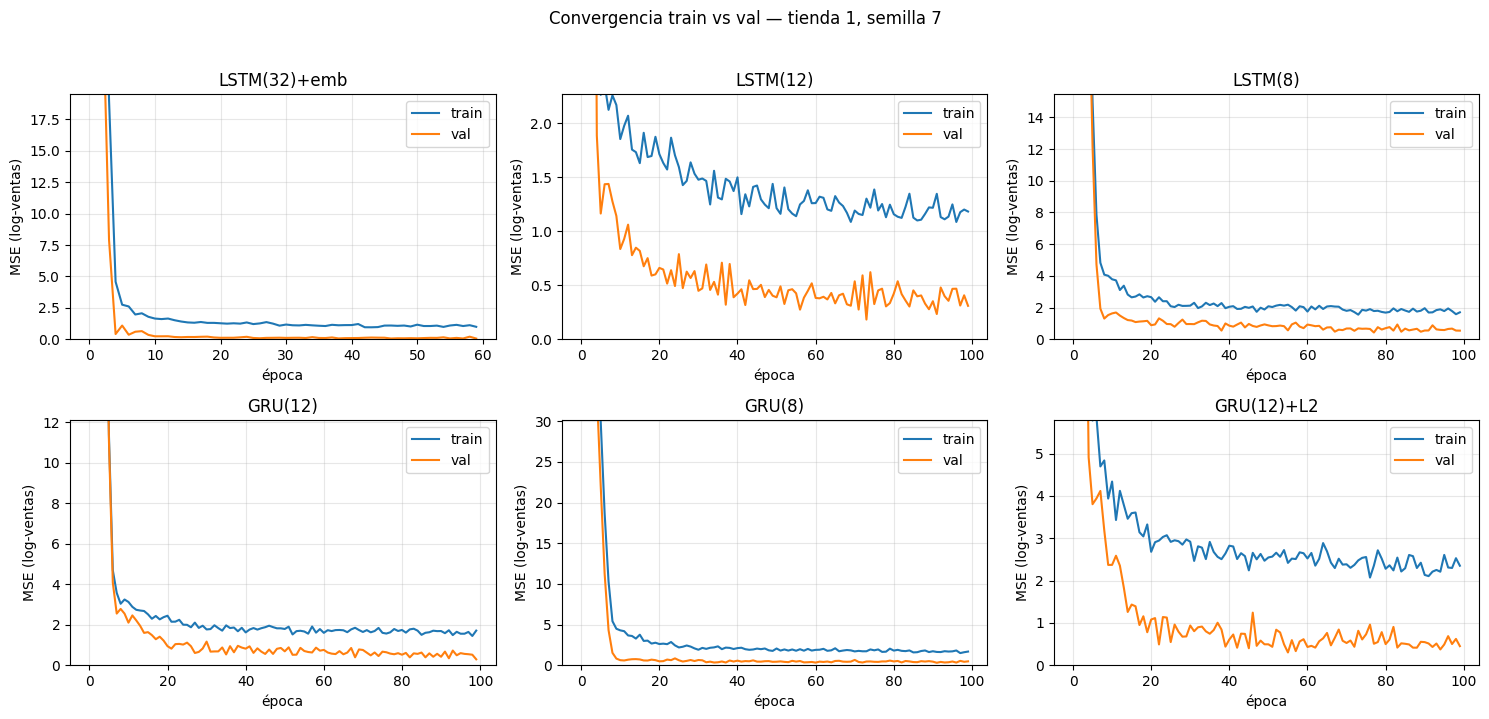

In [20]:
# ── Curvas de convergencia train vs val de cada arquitectura ─────────────────
from tensorflow.keras import backend as K

TIENDA_CURVA = 1     # tienda a inspeccionar (cámbiala si quieres)
SEED_CURVA   = 7

# (nombre, builder, funcion de inputs, epocas, batch_size)
variantes_curva = [
    ('LSTM(32)+emb', v1,  inp1,    60, 64),
    ('LSTM(12)',     v4,  inp_gru, 100, 32),
    ('LSTM(8)',      v5,  inp_gru, 100, 32),
    ('GRU(12)',      v2,  inp_gru, 100, 32),
    ('GRU(8)',       v3a, inp_gru, 100, 32),
    ('GRU(12)+L2',   v3b, inp_gru, 100, 32),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (nombre, f_modelo, f_inputs, ep, bs) in zip(axes.flat, variantes_curva):
    X_tr, y_tr_s = f_inputs(i_tr, TIENDA_CURVA)
    X_va, y_va_s = f_inputs(i_va, TIENDA_CURVA)
    K.clear_session(); np.random.seed(SEED_CURVA); tf.random.set_seed(SEED_CURVA)
    m = f_modelo()
    h = m.fit(X_tr, y_tr_s, validation_data=(X_va, y_va_s),
              epochs=ep, batch_size=bs, verbose=0)   # sin EarlyStopping: queremos la curva entera
    ax.plot(h.history['loss'],     label='train')
    ax.plot(h.history['val_loss'], label='val')
    ax.set_title(nombre); ax.set_xlabel('época'); ax.set_ylabel('MSE (log-ventas)')
    # recorta el eje Y para que un pico de val no aplaste la grafica
    ax.set_ylim(0, np.percentile(h.history['loss'] + h.history['val_loss'], 95))
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f'Convergencia train vs val — tienda {TIENDA_CURVA}, semilla {SEED_CURVA}', y=1.02)
plt.tight_layout(); plt.show()

### Comparativa LSTM vs GRU

== R2 global por variante ==
                            arquitectura  R2_global_medio  desv_semillas
LSTM(32)+emb                        LSTM            0.099          0.368
LSTM(12)                            LSTM            0.589          0.319
LSTM(8)                             LSTM            0.720          0.032
GRU(12)                              GRU            0.591          0.219
GRU(8)                               GRU            0.547          0.150
GRU(12)+L2                           GRU            0.204          0.230
Baseline (media tienda+dia)            -            0.886          0.000

== R2 por tienda (media de semillas) ==
     LSTM(32)+emb  LSTM(12)  LSTM(8)  GRU(12)  GRU(8)  GRU(12)+L2  Baseline
1        -163.137   -88.342   -5.298   -3.492 -25.250     -40.525    -0.073
2          -7.658    -2.104   -0.047  -16.887  -2.472     -27.605     0.448
3          -2.349    -0.271   -0.141   -0.006   0.007      -0.328     0.375
4          -0.501    -0.477   -2.441   -5.

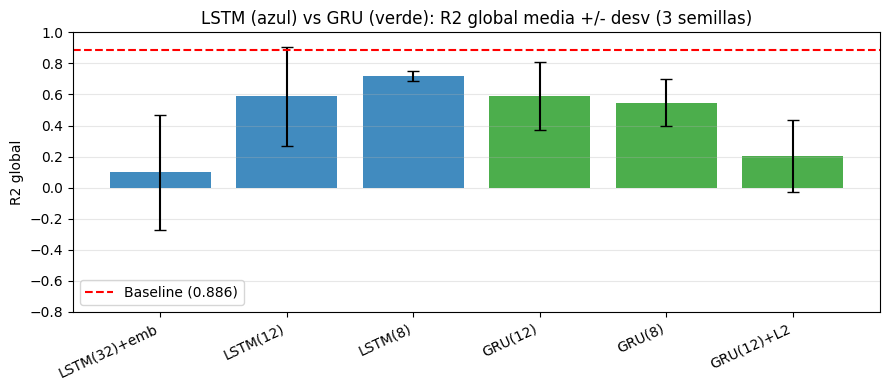


Mejor variante de la Estrategia A: LSTM(8)


,arquitectura,R2_global_medio,desv_semillas
LSTM(32)+emb,LSTM,0.099,0.368
LSTM(12),LSTM,0.589,0.319
LSTM(8),LSTM,0.720,0.032
GRU(12),GRU,0.591,0.219
GRU(8),GRU,0.547,0.150
GRU(12)+L2,GRU,0.204,0.230
Baseline (media tienda+dia),-,0.886,0.000


In [14]:
# ── Comparativa LSTM vs GRU (ejecutar tras entrenar ambos bloques) ───────────
orden = ['LSTM(32)+emb', 'LSTM(12)', 'LSTM(8)', 'GRU(12)', 'GRU(8)', 'GRU(12)+L2']
r2_base = round(r2_score(ventas_te, pred_base), 3)

tab_glob = pd.DataFrame({'arquitectura':    ['LSTM' if 'LSTM' in k else 'GRU' for k in orden],
                         'R2_global_medio': [round(res_global[k][0], 3) for k in orden],
                         'desv_semillas':   [round(res_global[k][1], 3) for k in orden]}, index=orden)
tab_glob.loc['Baseline (media tienda+dia)'] = ['-', r2_base, 0.0]
print('== R2 global por variante =='); print(tab_glob.to_string())

tab_st = pd.DataFrame({k: res_por_tienda[k] for k in orden}).round(3)
tab_st['Baseline'] = [round(r2_score(ventas_te[store_te == s], pred_base[store_te == s]), 3) for s in TIENDAS]
print('\n== R2 por tienda (media de semillas) =='); print(tab_st.to_string())

# Grafica de barras: media +/- desv, color por arquitectura
medias = [res_global[k][0] for k in orden]; desv = [res_global[k][1] for k in orden]
colores = ['tab:blue' if 'LSTM' in k else 'tab:green' for k in orden]
plt.figure(figsize=(9, 4))
plt.bar(range(len(orden)), medias, yerr=desv, color=colores, capsize=4, alpha=0.85)
plt.axhline(r2_base, color='red', ls='--', label=f'Baseline ({r2_base})')
plt.xticks(range(len(orden)), orden, rotation=25, ha='right')
plt.ylabel('R2 global'); plt.ylim(min(-0.8, min(medias) - 0.1), 1.0)
plt.title('LSTM (azul) vs GRU (verde): R2 global media +/- desv (3 semillas)')
plt.legend(); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

# La mejor variante (mayor R2 medio) alimenta la comparativa final entre estrategias
mejor_nombre = max(res_global, key=lambda k: res_global[k][0])
print('\nMejor variante de la Estrategia A:', mejor_nombre)
resultados[f'Estrategia A (por tienda, {mejor_nombre})'] = metricas(ventas_te, preds_var[mejor_nombre], store_te)
tab_glob

### Resultados y justificación (LSTM vs GRU)

1. *LSTM vs GRU: empate técnico. Comparando a igual número de unidades (8 y 12), ninguna arquitectura gana de forma consistente: en unos tamaños va por delante una y en otros la otra, y las diferencias son del orden de la desviación entre semillas. Con estos datos, el tipo de celda recurrente importa menos que el tamaño y el azar de la inicialización.
2. La capacidad pesa más que la arquitectura. El peor modelo, con diferencia, es el más grande (LSTM con muchas unidades y todos los embeddings): además de la peor media, es el de mayor desviación entre semillas (prácticamente una lotería). Demasiados parámetros para las ~550 muestras de entrenamiento por tienda. Reducir el tamaño y limitar las entradas (embedding de DayOfWeek + lags) es lo que más sube y estabiliza el R².
3. Estabilidad ≠ mejor media. Las variantes más pequeñas tienden a tener menor desviación entre semillas (son más fiables), aunque no siempre la mejor media. Es el trade-off sesgo-varianza, visible en las barras de error de la gráfica. Qué variante resulta "la mejor" cambia entre ejecuciones; lo robusto no es el ranking fino, sino que el óptimo está en tamaños pequeños-intermedios.
4. El R² global engaña. Aunque la mejor variante alcanza un R² global aparentemente decente, su R² por tienda es casi siempre negativo. El R² global se infla por las diferencias de nivel entre tiendas (acertar que una tienda vende el triple que otra ya explica mucha varianza agregada); pero dentro de cada tienda los modelos apenas capturan la dinámica. La métrica honesta es el R² por tienda.
5. Ninguna variante bate al baseline. Ni en global ni por tienda: la media por (tienda, día de la semana) ya captura el nivel y el ciclo semanal, que es casi toda la señal aprovechable con un histórico tan corto.
6. Sobre la reproducibilidad. Aplicamos clipping de la predicción, promediado de varias semillas y clear_session(). Aun así, los resultados no son reproducibles exactamente: con la misma semilla, los R² cambian entre ejecuciones y entre máquinas. La causa es que la semilla solo fija lo aleatorio (pesos iniciales, barajado), no la aritmética: en CPU, el paralelismo entre hilos y oneDNN reordenan las sumas en coma flotante, y como la suma no es asociativa, aparecen diferencias en los últimos decimales. Normalmente serían irrelevantes, pero estos modelos están tan mal condicionados (al borde de la divergencia con tan pocos datos) que esa diferencia mínima se amplifica hasta cambiar el resultado final. Esa fragilidad extrema es, en sí misma, el resultado principal de esta estrategia.
7. Conclusión. Con ~550 muestras por tienda, el modelo individual no es viable: no supera a un baseline trivial y es frágil hasta a nivel numérico. Esto motiva las Estrategias B (un modelo por grupo) y C (modelo global con embedding de Store), que comparten datos entre tiendas (pooling) para tener suficiente muestra.